# Pre-1870 Old Stock Ancestry: National Estimates, 1870-2020

This notebook runs the agent-based national ancestry model and visualizes:

1. **Percentage** of the U.S. population that is majority old-stock (non-Black pre-1870 resident ancestry) vs. not, decade by decade.
2. **Raw headcount** of those groups anchored to actual Census population totals.
3. **State-level map** of estimated old-stock ancestry share.
4. **Hypothetical 2024 Electoral College map** if only old-stock Americans were counted in the census.

See `ASSUMPTIONS.md` for full model documentation.

In [ ]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path(os.getcwd()).parent / "scripts"))

from dataclasses import asdict
from pre1870_ancestry_model import ModelParams, DECADE_DATA, simulate
from state_pre1870_ancestry_model import (
    FALLBACK_STATES, ModelParams as StateModelParams, estimate_states,
    weighted_mean, fetch_acs_state_inputs,
)
from state_agent_ancestry_model import (
    StateAgentModelParams, simulate_states as simulate_agent_states,
    build_state_decade_panel, weighted_mean as agent_weighted_mean,
)
from hypothetical_ec_reapportionment import (
    apportion_house_huntington_hill, EV_2024,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ---------------------------------------------------------------------------
# Substack-style theme
# ---------------------------------------------------------------------------
SUBSTACK_BG      = "#F7F5F0"
SUBSTACK_CARD    = "#EFEDE8"
SUBSTACK_TEXT    = "#1A1A1A"
SUBSTACK_MUTED   = "#6B6B6B"
SUBSTACK_ACCENT  = "#C85A3D"
SUBSTACK_BLUE    = "#3D6F8C"
SUBSTACK_GOLD    = "#C2993E"
SUBSTACK_GREEN   = "#4A7C59"
SUBSTACK_GRID    = "#D6D3CC"

plt.rcParams.update({
    "figure.facecolor":   SUBSTACK_BG,
    "axes.facecolor":     SUBSTACK_BG,
    "savefig.facecolor":  SUBSTACK_BG,
    "text.color":         SUBSTACK_TEXT,
    "axes.labelcolor":    SUBSTACK_TEXT,
    "xtick.color":        SUBSTACK_MUTED,
    "ytick.color":        SUBSTACK_MUTED,
    "axes.edgecolor":     SUBSTACK_GRID,
    "grid.color":         SUBSTACK_GRID,
    "grid.alpha":         0.6,
    "grid.linewidth":     0.5,
    "font.family":        "serif",
    "font.size":          12,
    "axes.titlesize":     16,
    "axes.labelsize":     13,
    "figure.titlesize":   18,
    "legend.framealpha":  0.0,
    "legend.fontsize":    11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

assert os.environ.get("CENSUS_API_KEY"), "Set CENSUS_API_KEY env var before running"

print("Setup complete.")

## 1. Run the national agent-based model

In [21]:
params = ModelParams(n_agents=300_000, seed=1870)
results = simulate(params)

years       = [r.year for r in results]
populations = [d.total_population for d in DECADE_DATA]

pct_majority_old_stock = [r.primary_qualifying_ancestry_share for r in results]
pct_any_old_stock      = [r.any_qualifying_ancestor_share for r in results]
pct_avg_ancestry       = [r.average_qualifying_ancestry for r in results]

pct_not_majority = [1.0 - p for p in pct_majority_old_stock]

raw_majority   = [pop * pct for pop, pct in zip(populations, pct_majority_old_stock)]
raw_not        = [pop * pct for pop, pct in zip(populations, pct_not_majority)]

df_national = pd.DataFrame({
    "year":               years,
    "population":         populations,
    "pct_majority_old":   pct_majority_old_stock,
    "pct_any_old":        pct_any_old_stock,
    "pct_avg_ancestry":   pct_avg_ancestry,
    "pct_not_majority":   pct_not_majority,
    "count_majority_old": raw_majority,
    "count_not_majority": raw_not,
})

df_national.style.format({
    "population":         "{:,.0f}",
    "pct_majority_old":   "{:.1%}",
    "pct_any_old":        "{:.1%}",
    "pct_avg_ancestry":   "{:.1%}",
    "pct_not_majority":   "{:.1%}",
    "count_majority_old": "{:,.0f}",
    "count_not_majority": "{:,.0f}",
})

,year,population,pct_majority_old,pct_any_old,pct_avg_ancestry,pct_not_majority,count_majority_old,count_not_majority
0,1870,"38,558,371",87.4%,87.4%,87.4%,12.6%,"33,680,866","4,877,505"
1,1880,"50,189,209",80.3%,82.9%,81.6%,19.7%,"40,277,844","9,911,365"
2,1890,"62,979,766",71.1%,76.4%,73.6%,28.9%,"44,771,266","18,208,500"
3,1900,"76,212,168",65.5%,73.8%,69.2%,34.5%,"49,913,127","26,299,041"
4,1910,"92,228,496",57.0%,67.4%,61.3%,43.0%,"52,529,970","39,698,526"
5,1920,"106,021,537",51.9%,64.9%,57.0%,48.1%,"55,073,594","50,947,943"
6,1930,"123,202,624",48.9%,64.3%,54.4%,51.1%,"60,188,178","63,014,446"
7,1940,"132,164,569",47.8%,65.9%,53.9%,52.2%,"63,229,733","68,934,836"
8,1950,"151,325,798",46.8%,67.4%,53.1%,53.2%,"70,859,818","80,465,980"
9,1960,"179,323,175",45.7%,68.6%,51.9%,54.3%,"81,971,014","97,352,161"


## 2. Share of America that is majority old-stock over time

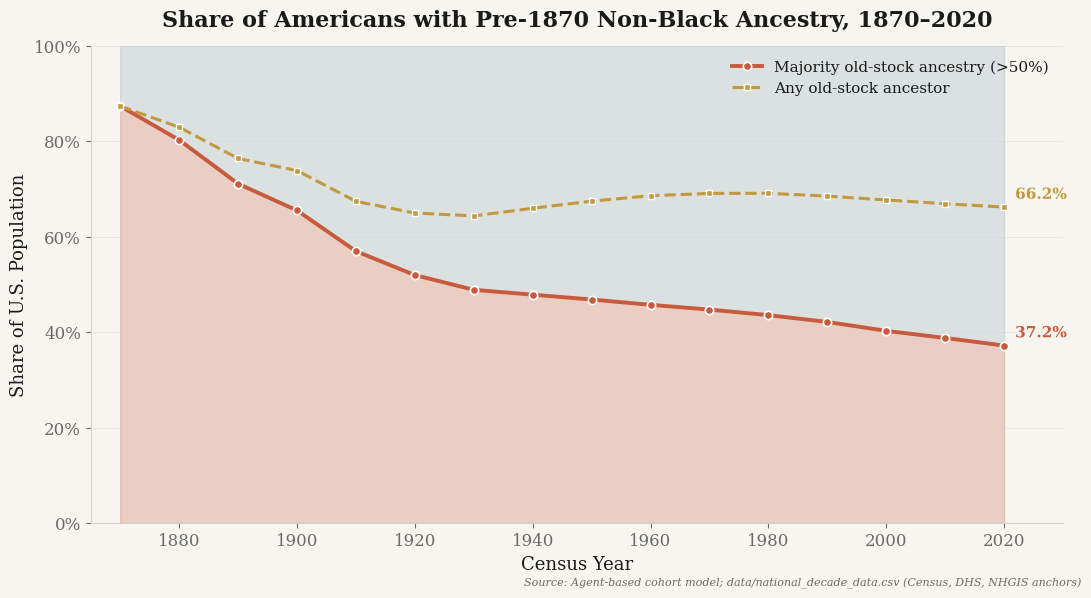

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(years, [p * 100 for p in pct_majority_old_stock], 0,
                color=SUBSTACK_ACCENT, alpha=0.25, label="_nolegend_")
ax.fill_between(years, 100, [p * 100 for p in pct_majority_old_stock],
                color=SUBSTACK_BLUE, alpha=0.15, label="_nolegend_")

ax.plot(years, [p * 100 for p in pct_majority_old_stock],
        color=SUBSTACK_ACCENT, linewidth=2.8, marker="o", markersize=6,
        markeredgecolor="white", markeredgewidth=1.2,
        label="Majority old-stock ancestry (>50%)")
ax.plot(years, [p * 100 for p in pct_any_old_stock],
        color=SUBSTACK_GOLD, linewidth=2.2, marker="s", markersize=5,
        markeredgecolor="white", markeredgewidth=1.0,
        label="Any old-stock ancestor", linestyle="--")

for val, label, color, va in [
    (pct_majority_old_stock[-1], f"{pct_majority_old_stock[-1]:.1%}", SUBSTACK_ACCENT, "bottom"),
    (pct_any_old_stock[-1],     f"{pct_any_old_stock[-1]:.1%}",      SUBSTACK_GOLD,   "bottom"),
]:
    ax.annotate(label, xy=(2020, val * 100), xytext=(8, 6 if va == "bottom" else -12),
                textcoords="offset points", fontsize=11, fontweight="bold", color=color,
                path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_BG)])

ax.set_xlim(1865, 2030)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Census Year")
ax.set_ylabel("Share of U.S. Population")
ax.set_title("Share of Americans with Pre-1870 Non-Black Ancestry, 1870–2020",
             fontweight="bold", pad=14)
ax.legend(loc="upper right", frameon=False)
ax.grid(axis="y", linestyle="-", linewidth=0.5)

fig.text(0.99, 0.01,
         "Source: Agent-based cohort model; data/national_decade_data.csv (Census, DHS, NHGIS anchors)",
         ha="right", fontsize=8, color=SUBSTACK_MUTED, style="italic")
plt.tight_layout()
plt.savefig("../outputs/pct_old_stock_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Raw headcount: majority old-stock vs. not

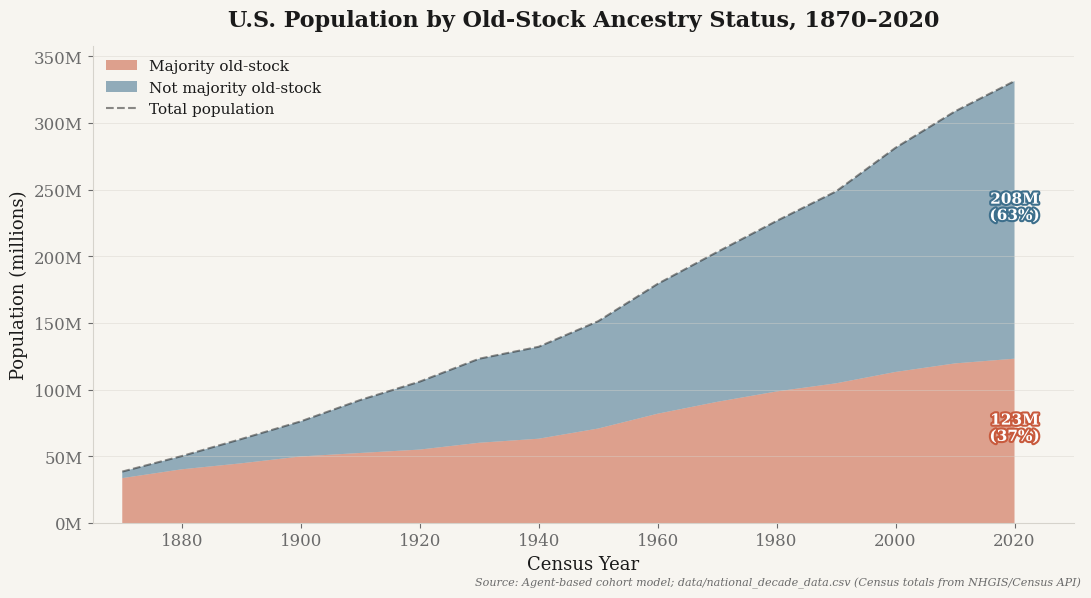

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))

raw_maj_m = [x / 1e6 for x in raw_majority]
raw_not_m = [x / 1e6 for x in raw_not]
pop_m     = [x / 1e6 for x in populations]

ax.stackplot(years, raw_maj_m, raw_not_m,
             colors=[SUBSTACK_ACCENT, SUBSTACK_BLUE],
             alpha=0.55,
             labels=["Majority old-stock", "Not majority old-stock"])

ax.plot(years, pop_m, color=SUBSTACK_TEXT, linewidth=1.5, linestyle="--",
        alpha=0.5, label="Total population")

y_maj = raw_maj_m[-1]
y_not = raw_not_m[-1]
ax.annotate(f"{y_maj:.0f}M\n({pct_majority_old_stock[-1]:.0%})",
            xy=(2020, y_maj / 2), fontsize=11, fontweight="bold",
            color="white", ha="center",
            path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_ACCENT)])
ax.annotate(f"{y_not:.0f}M\n({pct_not_majority[-1]:.0%})",
            xy=(2020, y_maj + y_not / 2), fontsize=11, fontweight="bold",
            color="white", ha="center",
            path_effects=[pe.withStroke(linewidth=3, foreground=SUBSTACK_BLUE)])

ax.set_xlim(1865, 2030)
ax.set_ylim(0, max(pop_m) * 1.08)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.set_xlabel("Census Year")
ax.set_ylabel("Population (millions)")
ax.set_title("U.S. Population by Old-Stock Ancestry Status, 1870–2020",
             fontweight="bold", pad=14)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="-", linewidth=0.5)

fig.text(0.99, 0.01,
         "Source: Agent-based cohort model; data/national_decade_data.csv (Census totals from NHGIS/Census API)",
         ha="right", fontsize=8, color=SUBSTACK_MUTED, style="italic")
plt.tight_layout()
plt.savefig("../outputs/raw_headcount_old_stock.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. State-level estimates: two methods compared

**Method A — Reduced-form model** (original): Uses ACS foreign-born and Black-alone
shares with hand-set `old_stock_factor` per state, calibrated to national anchors.

**Method B — Agent-based simulation** (new): Runs 300K agents through 1870-2020 with
per-state historical Census data (NHGIS panel: population, race, nativity by decade).
No hand-set factors — state differences emerge from the simulation.

In [24]:
# ── Method A: Reduced-form model with ACS data ──────────────────────────
state_params = StateModelParams()
inputs = fetch_acs_state_inputs(2022, os.environ["CENSUS_API_KEY"])
estimates_rf = estimate_states(inputs, state_params)

df_rf = pd.DataFrame([asdict(e) for e in estimates_rf])
df_rf["qualifying_pct"] = df_rf["primary_qualifying_ancestry_share"] * 100

print(f"Method A (reduced-form): {len(df_rf)} states")
print(f"  Data: ACS 2022 5-year (foreign-born, Black-alone) + hand-set old_stock_factor")
print(f"  National weighted primary share: {weighted_mean(estimates_rf, 'primary_qualifying_ancestry_share'):.1%}")

# ── Method B: Agent-based simulation with NHGIS historical data ──────────
DATA = pathlib.Path(os.getcwd()).parent / "data"
panel = build_state_decade_panel(
    DATA / "nhgis_historical_state_panel_1790_1990.csv",
    DATA / "modern_census_state_race_2000_2020.csv",
)

agent_params = StateAgentModelParams(n_agents=300_000, seed=1870)
estimates_agent = simulate_agent_states(agent_params, panel)

df_agent = pd.DataFrame([asdict(e) for e in estimates_agent])
df_agent["qualifying_pct"] = df_agent["primary_qualifying_ancestry_share"] * 100

print(f"\nMethod B (agent-based): {len(df_agent)} states")
print(f"  Data: NHGIS historical panel 1790-1990 + Census 2000-2020 (pop, race, nativity)")
print(f"  National weighted primary share: {agent_weighted_mean(estimates_agent, 'primary_qualifying_ancestry_share'):.1%}")

# ── Use the agent-based model as the primary state estimates ─────────────
df_state = df_agent.copy()
estimates = estimates_agent

df_state["counted_population"] = df_state["population"] * df_state["primary_qualifying_ancestry_share"]

state_pops = dict(zip(
    df_state[df_state["abbr"] != "DC"]["abbr"],
    df_state[df_state["abbr"] != "DC"]["counted_population"],
))
hyp_house = apportion_house_huntington_hill(state_pops)

df_state["actual_ev_2024"]    = df_state["abbr"].map(EV_2024)
df_state["hypothetical_house"] = df_state["abbr"].map(hyp_house).fillna(0).astype(int)
df_state["hypothetical_ev"]   = df_state.apply(
    lambda r: 3 if r["abbr"] == "DC" else r["hypothetical_house"] + 2, axis=1
)
df_state["ev_change"] = df_state["hypothetical_ev"] - df_state["actual_ev_2024"]

print(f"\nTotal actual 2024 EV: {df_state['actual_ev_2024'].sum()}")
print(f"Total hypothetical EV: {df_state['hypothetical_ev'].sum()}")

Method A (reduced-form): 51 states
  Data: ACS 2022 5-year (foreign-born, Black-alone) + hand-set old_stock_factor
  National weighted primary share: 37.2%

Method B (agent-based): 51 states
  Data: NHGIS historical panel 1790-1990 + Census 2000-2020 (pop, race, nativity)
  National weighted primary share: 35.5%

Total actual 2024 EV: 538
Total hypothetical EV: 538


In [25]:
# ── Method comparison table ──────────────────────────────────────────────
df_compare = df_rf[["abbr", "state", "qualifying_pct"]].merge(
    df_agent[["abbr", "qualifying_pct"]], on="abbr", suffixes=("_rf", "_agent"),
)
df_compare["diff"] = df_compare["qualifying_pct_agent"] - df_compare["qualifying_pct_rf"]
df_compare = df_compare.sort_values("diff", key=abs, ascending=False)

print("Largest divergences between reduced-form (A) and agent-based (B):")
print(f"{'State':<22} {'RF %':>6} {'Agent %':>8} {'Diff':>6}")
print("-" * 45)
for _, r in df_compare.head(15).iterrows():
    print(f"{r['state']:<22} {r['qualifying_pct_rf']:5.1f}% {r['qualifying_pct_agent']:7.1f}% {r['diff']:+5.1f}%")

df_compare.rename(columns={
    "state": "State", "abbr": "Abbr",
    "qualifying_pct_rf": "Reduced-Form %",
    "qualifying_pct_agent": "Agent-Based %",
    "diff": "Difference",
}).style.format({
    "Reduced-Form %": "{:.1f}%",
    "Agent-Based %": "{:.1f}%",
    "Difference": "{:+.1f}%",
}).bar(subset=["Difference"], color=[SUBSTACK_BLUE, SUBSTACK_ACCENT], align="zero")

Largest divergences between reduced-form (A) and agent-based (B):
State                    RF %  Agent %   Diff
---------------------------------------------
New Hampshire           70.4%    32.6% -37.9%
North Dakota            53.1%    17.3% -35.8%
Wisconsin               61.2%    28.4% -32.8%
New Mexico              30.5%    62.8% +32.2%
Vermont                 75.1%    45.7% -29.3%
Montana                 52.6%    25.9% -26.7%
Minnesota               52.9%    26.6% -26.2%
Michigan                49.5%    24.4% -25.1%
Rhode Island            41.1%    17.2% -23.9%
Massachusetts           39.0%    16.3% -22.7%
Wyoming                 48.8%    26.6% -22.2%
Hawaii                  14.5%    35.8% +21.4%
District of Columbia    11.8%    32.5% +20.7%
Maine                   74.8%    54.4% -20.4%
Connecticut             40.6%    23.0% -17.6%


,Abbr,State,Reduced-Form %,Agent-Based %,Difference
29,NH,New Hampshire,70.4%,32.6%,-37.9%
34,ND,North Dakota,53.1%,17.3%,-35.8%
49,WI,Wisconsin,61.2%,28.4%,-32.8%
31,NM,New Mexico,30.5%,62.8%,+32.2%
45,VT,Vermont,75.1%,45.7%,-29.3%
26,MT,Montana,52.6%,25.9%,-26.7%
23,MN,Minnesota,52.9%,26.6%,-26.2%
22,MI,Michigan,49.5%,24.4%,-25.1%
39,RI,Rhode Island,41.1%,17.2%,-23.9%
21,MA,Massachusetts,39.0%,16.3%,-22.7%


### Map A: Primary old-stock ancestry share by state

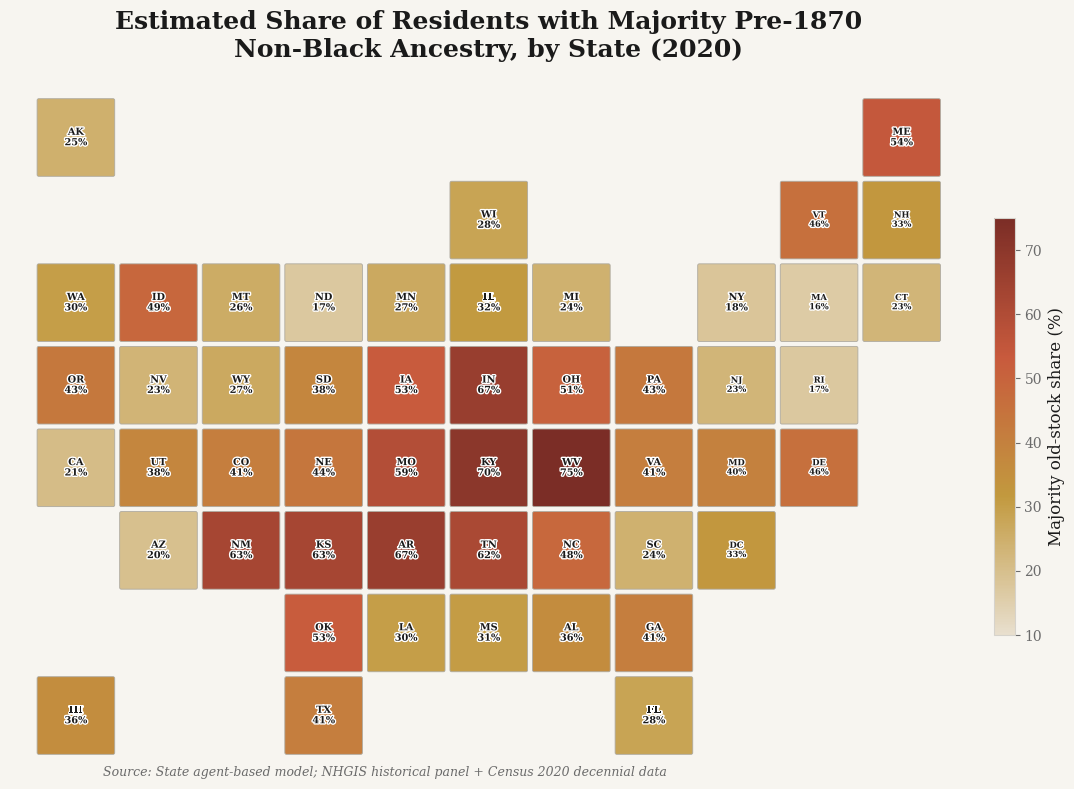

In [26]:
from matplotlib.patches import FancyBboxPatch

TILE = {
    'AK': (0, 0),  'ME': (10, 0),
    'WI': (5, 1),  'VT': (9, 1),  'NH': (10, 1),
    'WA': (0, 2),  'ID': (1, 2),  'MT': (2, 2),  'ND': (3, 2),  'MN': (4, 2),
    'IL': (5, 2),  'MI': (6, 2),  'NY': (8, 2),  'MA': (9, 2),  'CT': (10, 2),
    'OR': (0, 3),  'NV': (1, 3),  'WY': (2, 3),  'SD': (3, 3),  'IA': (4, 3),
    'IN': (5, 3),  'OH': (6, 3),  'PA': (7, 3),  'NJ': (8, 3),  'RI': (9, 3),
    'CA': (0, 4),  'UT': (1, 4),  'CO': (2, 4),  'NE': (3, 4),  'MO': (4, 4),
    'KY': (5, 4),  'WV': (6, 4),  'VA': (7, 4),  'MD': (8, 4),  'DE': (9, 4),
    'AZ': (1, 5),  'NM': (2, 5),  'KS': (3, 5),  'AR': (4, 5),  'TN': (5, 5),
    'NC': (6, 5),  'SC': (7, 5),  'DC': (8, 5),
    'OK': (3, 6),  'LA': (4, 6),  'MS': (5, 6),  'AL': (6, 6),  'GA': (7, 6),
    'HI': (0, 7),  'TX': (3, 7),  'FL': (7, 7),
}

old_stock_cmap = LinearSegmentedColormap.from_list(
    "old_stock", ["#E8DFCE", SUBSTACK_GOLD, SUBSTACK_ACCENT, "#7B2D26"], N=256
)
norm = plt.Normalize(vmin=10, vmax=75)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_axis_off()

for _, row in df_state.iterrows():
    abbr = row["abbr"]
    if abbr not in TILE:
        continue
    col, grow = TILE[abbr]
    pct = row["qualifying_pct"]
    color = old_stock_cmap(norm(pct))
    rect = FancyBboxPatch((col - 0.45, -grow - 0.45), 0.9, 0.9,
                          boxstyle="round,pad=0.02", facecolor=color,
                          edgecolor="#AEAAA0", linewidth=0.6)
    ax.add_patch(rect)
    fs = 6 if abbr in ("DC", "RI", "DE", "CT", "NJ", "NH", "VT", "MA", "MD") else 7
    ax.annotate(f"{abbr}\n{pct:.0f}%", xy=(col, -grow), ha="center", va="center",
                fontsize=fs, fontweight="bold", color=SUBSTACK_TEXT,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

ax.autoscale_view()
ax.set_aspect("equal")
ax.margins(0.03)

sm = plt.cm.ScalarMappable(cmap=old_stock_cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label("Majority old-stock share (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_edgecolor(SUBSTACK_GRID)

ax.set_title("Estimated Share of Residents with Majority Pre-1870\nNon-Black Ancestry, by State (2020)",
             fontsize=18, fontweight="bold", pad=16)
fig.text(0.5, 0.02,
         "Source: State agent-based model; NHGIS historical panel + Census 2020 decennial data",
         ha="center", fontsize=9, color=SUBSTACK_MUTED, style="italic")

plt.tight_layout()
plt.savefig("../outputs/map_old_stock_pct_by_state.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Hypothetical 2024 Electoral College map

If the census only counted residents with majority pre-1870 non-Black ancestry, how would the 435 House seats (and therefore electoral votes) be redistributed?

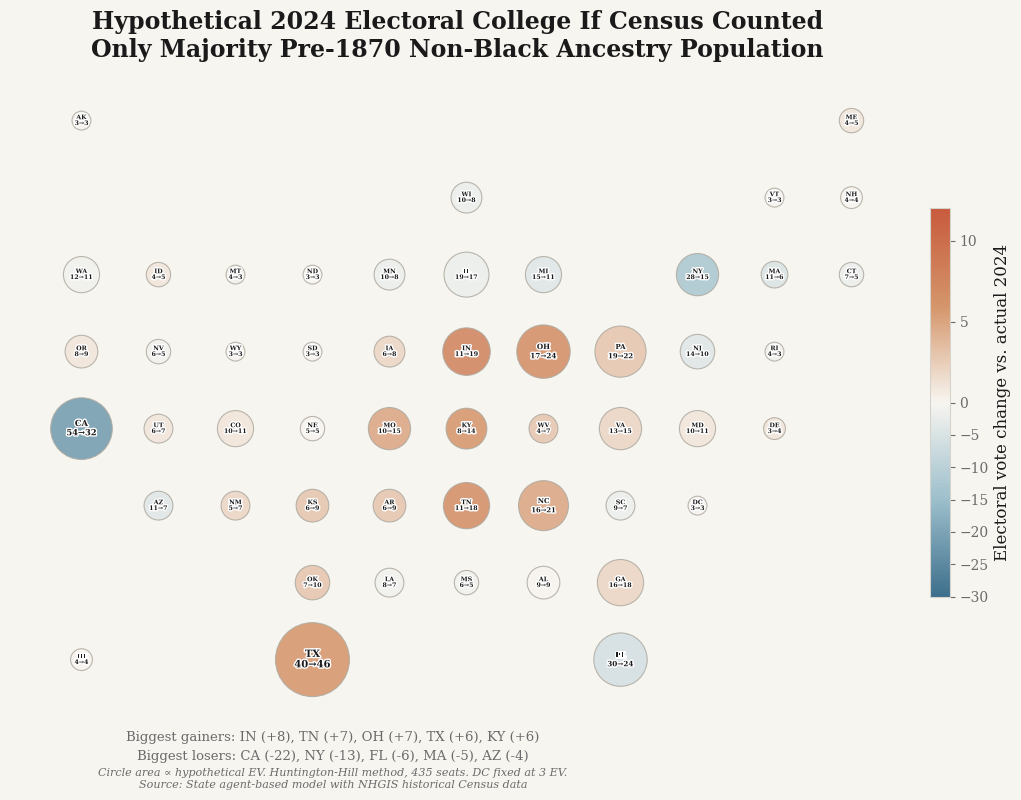

In [27]:
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection

TILE_EC = {
    'AK': (0, 0),  'ME': (10, 0),
    'WI': (5, 1),  'VT': (9, 1),  'NH': (10, 1),
    'WA': (0, 2),  'ID': (1, 2),  'MT': (2, 2),  'ND': (3, 2),  'MN': (4, 2),
    'IL': (5, 2),  'MI': (6, 2),  'NY': (8, 2),  'MA': (9, 2),  'CT': (10, 2),
    'OR': (0, 3),  'NV': (1, 3),  'WY': (2, 3),  'SD': (3, 3),  'IA': (4, 3),
    'IN': (5, 3),  'OH': (6, 3),  'PA': (7, 3),  'NJ': (8, 3),  'RI': (9, 3),
    'CA': (0, 4),  'UT': (1, 4),  'CO': (2, 4),  'NE': (3, 4),  'MO': (4, 4),
    'KY': (5, 4),  'WV': (6, 4),  'VA': (7, 4),  'MD': (8, 4),  'DE': (9, 4),
    'AZ': (1, 5),  'NM': (2, 5),  'KS': (3, 5),  'AR': (4, 5),  'TN': (5, 5),
    'NC': (6, 5),  'SC': (7, 5),  'DC': (8, 5),
    'OK': (3, 6),  'LA': (4, 6),  'MS': (5, 6),  'AL': (6, 6),  'GA': (7, 6),
    'HI': (0, 7),  'TX': (3, 7),  'FL': (7, 7),
}

CELL = 1.0
MAX_R = CELL * 0.48

ev_cmap = LinearSegmentedColormap.from_list(
    "ev_change", [SUBSTACK_BLUE, "#9DBFCC", SUBSTACK_BG, "#D4956A", SUBSTACK_ACCENT], N=256
)
ev_norm = TwoSlopeNorm(vmin=-30, vcenter=0, vmax=12)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_axis_off()

max_ev = df_state["hypothetical_ev"].max()

patches, colors_arr, labels_info = [], [], []
for _, row in df_state.iterrows():
    abbr = row["abbr"]
    if abbr not in TILE_EC:
        continue
    col, grow = TILE_EC[abbr]
    cx, cy = col * CELL, -grow * CELL
    ev = row["hypothetical_ev"]
    r = MAX_R * np.sqrt(ev / max_ev)
    patches.append(Circle((cx, cy), r))
    colors_arr.append(row["ev_change"])
    labels_info.append((cx, cy, abbr, int(row["actual_ev_2024"]), int(ev), r))

pc = PatchCollection(patches, cmap=ev_cmap, norm=ev_norm,
                      edgecolor="#AEAAA0", linewidth=0.8, alpha=0.85)
pc.set_array(np.array(colors_arr))
ax.add_collection(pc)

for cx, cy, abbr, actual, hyp, r in labels_info:
    fs = np.clip(r * 15, 4.5, 8)
    ax.annotate(f"{abbr}\n{actual}→{hyp}", xy=(cx, cy), ha="center", va="center",
                fontsize=fs, fontweight="bold", color=SUBSTACK_TEXT,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")], zorder=4)

ax.autoscale_view()
ax.set_aspect("equal")
ax.margins(0.05)

sm = plt.cm.ScalarMappable(cmap=ev_cmap, norm=ev_norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label("Electoral vote change vs. actual 2024", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_edgecolor(SUBSTACK_GRID)

ax.set_title("Hypothetical 2024 Electoral College If Census Counted\nOnly Majority Pre-1870 Non-Black Ancestry Population",
             fontsize=17, fontweight="bold", pad=16)

gainers = df_state[df_state["ev_change"] > 0].sort_values("ev_change", ascending=False)
losers  = df_state[df_state["ev_change"] < 0].sort_values("ev_change")
top_gain = ", ".join(f"{r['abbr']} ({int(r['ev_change']):+d})" for _, r in gainers.head(5).iterrows())
top_lose = ", ".join(f"{r['abbr']} ({int(r['ev_change']):+d})" for _, r in losers.head(5).iterrows())

fig.text(0.5, 0.04,
         f"Biggest gainers: {top_gain}\nBiggest losers: {top_lose}",
         ha="center", fontsize=9.5, color=SUBSTACK_MUTED, linespacing=1.6)
fig.text(0.5, 0.005,
         "Circle area ∝ hypothetical EV. Huntington-Hill method, 435 seats. DC fixed at 3 EV.\n"
         "Source: State agent-based model with NHGIS historical Census data",
         ha="center", fontsize=8, color=SUBSTACK_MUTED, style="italic")

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("../outputs/map_hypothetical_ec_2024_cartogram.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Summary table: top gainers and losers

In [28]:
display_cols = ["state", "abbr", "qualifying_pct", "actual_ev_2024", "hypothetical_ev", "ev_change"]
rename = {"state": "State", "abbr": "Abbr", "qualifying_pct": "Old-Stock %",
          "actual_ev_2024": "Actual EV", "hypothetical_ev": "Hyp. EV", "ev_change": "Change"}

combined = pd.concat([
    pd.DataFrame(df_state.nlargest(10, "ev_change")[display_cols]),
    pd.DataFrame(df_state.nsmallest(10, "ev_change")[display_cols]),
]).rename(columns=rename)

combined.style.format({"Old-Stock %": "{:.1f}%"}).bar(
    subset=["Change"], color=[SUBSTACK_BLUE, SUBSTACK_ACCENT], align="zero"
)

,State,Abbr,Old-Stock %,Actual EV,Hyp. EV,Change
15,Indiana,IN,66.7%,11,19,8
35,Ohio,OH,50.5%,17,24,7
42,Tennessee,TN,61.6%,11,18,7
17,Kentucky,KY,70.2%,8,14,6
43,Texas,TX,41.2%,40,46,6
24,Missouri,MO,59.2%,10,15,5
27,North Carolina,NC,48.4%,16,21,5
2,Arkansas,AR,66.6%,6,9,3
16,Kansas,KS,62.7%,6,9,3
36,Oklahoma,OK,52.7%,7,10,3
